In [2]:
from pathlib import Path
import re

import numpy as np
import scipy.signal as sgn
from scipy.io import loadmat

folder = Path(r"C:\Users\saber\thesis_second_try\data\Rest\Respiration_ECG_Raw")

FS_IN = 1000
FS_OUT = 60
WIN_LEN = 2048
STRIDE = WIN_LEN  # non-overlap

SIGNAL_ORDER = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]

# --- experiment: keep only these signals (channels) ---
KEEP_SIGNALS = ["ECG_mV", "Cannula"]  # ECG + Cannula only

# Optimal scales for each
SCALE = {
    "ECG_mV": 1000.0,      # V -> mV
    "Fingerpulse": 10.0,
    "Cannula": 10.0,
    "Thermopod": 1.0
}

# Baseline Filter function
# https://github.com/antonior92/ecg-preprocessing/blob/64a2715b15ea5ee1a482e5319d2cbaf45edef6f4/ecgprep/preprocess.py#L30C1-L40C15
def remove_baseline_filter(sample_rate: int):
    fc = 0.8
    fst = 0.2
    rp = 0.5
    rs = 40

    wn = fc / (sample_rate / 2)
    wst = fst / (sample_rate / 2)
    order, _ = sgn.ellipord(wn, wst, rp, rs)
    sos = sgn.iirfilter(order, wn, rp, rs, btype="high", ftype="ellip", output="sos")
    return sos

SOS = remove_baseline_filter(FS_IN)

# One file -> (n_windows, len(KEEP_SIGNALS), WIN_LEN)
def preprocess_one_file(mat_path: Path) -> np.ndarray:
    m = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    rs = m["resting_state"]

    # baseline removal (filter at original sampling rate)
    ecg_f   = sgn.sosfiltfilt(SOS, rs.ECG)
    fp_f    = sgn.sosfiltfilt(SOS, rs.Fingerpulse)
    can_f   = sgn.sosfiltfilt(SOS, rs.Cannula)
    therm_f = sgn.sosfiltfilt(SOS, rs.Thermopod)

    # resample to 60 Hz
    ecg_60   = sgn.resample_poly(ecg_f,   up=FS_OUT, down=FS_IN)
    fp_60    = sgn.resample_poly(fp_f,    up=FS_OUT, down=FS_IN)
    can_60   = sgn.resample_poly(can_f,   up=FS_OUT, down=FS_IN)
    therm_60 = sgn.resample_poly(therm_f, up=FS_OUT, down=FS_IN)

    # scale
    ecg_60   = ecg_60   * SCALE["ECG_mV"]
    fp_60    = fp_60    * SCALE["Fingerpulse"]
    can_60   = can_60   * SCALE["Cannula"]
    therm_60 = therm_60 * SCALE["Thermopod"]

    # windowing (use STRIDE, not WIN_LEN hardcoded)
    L = len(ecg_60)  # all signals same length after resample
    starts = np.arange(0, L - WIN_LEN + 1, STRIDE)

    n_windows = len(starts)
    n_ch = len(KEEP_SIGNALS)
    tensor = np.zeros((n_windows, n_ch, WIN_LEN), dtype=np.float32)

    # map signal names to arrays
    sig = {
        "ECG_mV": ecg_60,
        "Fingerpulse": fp_60,
        "Cannula": can_60,
        "Thermopod": therm_60,
    }

    # fill only the kept signals, in the order of KEEP_SIGNALS
    for i, s in enumerate(starts):
        for j, name in enumerate(KEEP_SIGNALS):
            tensor[i, j, :] = sig[name][s:s + WIN_LEN]

    return tensor

# ----------------------------
# Run over all participant files
# ----------------------------
mat_files = sorted(folder.glob("*.mat"))

participant_files = [f for f in mat_files if f.name.startswith("resting_state_participant_")]

print("Total .mat files:", len(mat_files))
print("Participant files:", len(participant_files))

# ----------------------------
# Split into nose vs mouth
# ----------------------------
nose_files, mouth_files, skipped = [], [], []

for f in participant_files:
    m = re.search(r"participant_(\d+)", f.stem)
    if not m:
        skipped.append(f.name)
        continue

    pid = int(m.group(1))

    if 10 <= pid <= 112:
        nose_files.append(f)
    elif 200 <= pid <= 312:
        mouth_files.append(f)
    else:
        skipped.append(f.name)

print("Nose files :", len(nose_files))
print("Mouth files:", len(mouth_files))
print("Skipped    :", len(skipped))

# ----------------------------
# Preprocess each group
# ----------------------------
nose_tensors_by_participant = {}
mouth_tensors_by_participant = {}
failed = []

for f in nose_files:
    try:
        nose_tensors_by_participant[f.stem] = preprocess_one_file(f)
    except Exception as e:
        failed.append((f.name, "nose", str(e)))

for f in mouth_files:
    try:
        mouth_tensors_by_participant[f.stem] = preprocess_one_file(f)
    except Exception as e:
        failed.append((f.name, "mouth", str(e)))

print("Processed nose :", len(nose_tensors_by_participant))
print("Processed mouth:", len(mouth_tensors_by_participant))
print("Failed:", len(failed))

# ----------------------------
# Stack (only if consistent shapes inside each group)
# ----------------------------
if len(nose_tensors_by_participant) > 0:
    nose_keys = sorted(nose_tensors_by_participant.keys())
    X_nose = np.stack([nose_tensors_by_participant[k] for k in nose_keys], axis=0)
    print("X_nose shape:", X_nose.shape)  # (P_nose, n_windows, 2, 2048)

if len(mouth_tensors_by_participant) > 0:
    mouth_keys = sorted(mouth_tensors_by_participant.keys())
    X_mouth = np.stack([mouth_tensors_by_participant[k] for k in mouth_keys], axis=0)
    print("X_mouth shape:", X_mouth.shape)  # (P_mouth, n_windows, 2, 2048)


Total .mat files: 207
Participant files: 205
Nose files : 102
Mouth files: 103
Skipped    : 0
Processed nose : 102
Processed mouth: 103
Failed: 0
X_nose shape: (102, 9, 2, 2048)
X_mouth shape: (103, 9, 2, 2048)


In [3]:
import pandas as pd

Path_subject = r"C:\Users\saber\thesis_second_try\data\Rest\Subject info_study_1.csv"
df_subject = pd.read_csv(Path_subject)

df_subject.head()


,Subject Number,Gender,Age
0,1,Male,27
1,2,Female,29
2,3,Female,24
3,4,Male,21
4,5,Female,20


In [4]:
print(df_subject["Gender"].unique())


['Male' 'Female' 'Female ']


In [5]:
gender_map = {'Male': 1, 'Female': 0, 'Female ': 0 }

df_subject['Gender'] = df_subject['Gender'].map(gender_map).astype('Int64') # .astype('Int64') converted 0.0 or 1.0 to 0 and 1 


df_nose = df_subject.copy()
df_mouth= df_subject.copy()
df_subject.head()

,Subject Number,Gender,Age
0,1,1,27
1,2,0,29
2,3,0,24
3,4,1,21
4,5,0,20


In [6]:
missing_subjects_nose = [1,2,3,4,5,6,7,8,9,32]
missing_subjects_mouth =  [2, 3, 4, 5, 6, 7, 8, 9, 55]

df_nose = df_nose[~df_nose['Subject Number'].isin(missing_subjects_nose)]
df_mouth = df_mouth[~df_mouth['Subject Number'].isin(missing_subjects_mouth)]
print (df_nose.shape, df_mouth.shape)


(102, 3) (103, 3)


In [7]:
df_mouth.head()

,Subject Number,Gender,Age
0,1,1,27
9,10,1,37
10,11,1,29
11,12,0,25
12,13,0,31


try 2 modeling vs prediction of gender 

In [8]:
import re
import numpy as np

nose_keys = sorted(nose_tensors_by_participant.keys())  # same order as X_nose stacking
X_nose = np.stack([nose_tensors_by_participant[k] for k in nose_keys], axis=0)

print("X_nose shape:", X_nose.shape)
print("First 5 keys:", nose_keys[:5])


X_nose shape: (102, 9, 2, 2048)
First 5 keys: ['resting_state_participant_010', 'resting_state_participant_011', 'resting_state_participant_012', 'resting_state_participant_013', 'resting_state_participant_014']


In [9]:

def stem_to_subject_id(stem: str) -> int:
    m = re.search(r"participant_(\d+)", stem)
    if not m:
        raise ValueError(f"Could not parse participant id from: {stem}")
    return int(m.group(1))

nose_ids_from_files = np.array([stem_to_subject_id(k) for k in nose_keys], dtype=int)

print("First 10 subject IDs from files:", nose_ids_from_files[:10])
print("Number of participants from files:", len(nose_ids_from_files))
print("Unique IDs:", len(np.unique(nose_ids_from_files)))


First 10 subject IDs from files: [10 11 12 13 14 15 16 17 18 19]
Number of participants from files: 102
Unique IDs: 102


In [10]:
# label lookup from df_nose and create y_nose in the SAME ORDER as X_nose
df_nose["Subject Number"] = df_nose["Subject Number"].astype(int)
print(df_nose["Subject Number"])
df_nose["Gender"] = df_nose["Gender"].astype(int)
print(df_nose["Gender"])

9       10
10      11
11      12
12      13
13      14
      ... 
107    108
108    109
109    110
110    111
111    112
Name: Subject Number, Length: 102, dtype: int32
9      1
10     1
11     0
12     0
13     0
      ..
107    1
108    1
109    0
110    0
111    1
Name: Gender, Length: 102, dtype: int32


In [11]:
gender_by_subject = dict(zip(df_nose["Subject Number"], df_nose["Gender"]))
gender_by_subject # this is subject id and their correct gender 

{10: 1,
 11: 1,
 12: 0,
 13: 0,
 14: 0,
 15: 0,
 16: 0,
 17: 0,
 18: 0,
 19: 0,
 20: 1,
 21: 0,
 22: 0,
 23: 0,
 24: 0,
 25: 0,
 26: 0,
 27: 0,
 28: 1,
 29: 1,
 30: 1,
 31: 0,
 33: 0,
 34: 0,
 35: 0,
 36: 0,
 37: 1,
 38: 0,
 39: 1,
 40: 0,
 41: 0,
 42: 0,
 43: 0,
 44: 0,
 45: 0,
 46: 0,
 47: 0,
 48: 1,
 49: 0,
 50: 1,
 51: 0,
 52: 0,
 53: 1,
 54: 1,
 55: 0,
 56: 0,
 57: 1,
 58: 0,
 59: 1,
 60: 0,
 61: 0,
 62: 0,
 63: 0,
 64: 1,
 65: 0,
 66: 0,
 67: 1,
 68: 1,
 69: 1,
 70: 1,
 71: 0,
 72: 0,
 73: 1,
 74: 0,
 75: 0,
 76: 0,
 77: 1,
 78: 0,
 79: 0,
 80: 0,
 81: 0,
 82: 0,
 83: 0,
 84: 0,
 85: 1,
 86: 1,
 87: 1,
 88: 0,
 89: 0,
 90: 0,
 91: 1,
 92: 0,
 93: 1,
 94: 0,
 95: 1,
 96: 0,
 97: 1,
 98: 1,
 99: 1,
 100: 1,
 101: 1,
 102: 0,
 103: 1,
 104: 0,
 105: 1,
 106: 0,
 107: 0,
 108: 1,
 109: 1,
 110: 0,
 111: 0,
 112: 1}

In [12]:
# y_nose aligned to X_nose
y_nose = np.array([gender_by_subject[sid] for sid in nose_ids_from_files], dtype=int)
print("y_nose gender:", y_nose)
print("y_nose shape:", y_nose.shape)
print("Gender counts [0,1]:", np.bincount(y_nose))


y_nose gender: [1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0
 1 0 1 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0
 1 1 1 0 0 0 1 0 1 0 1 0 1 1 1 1 1 0 1 0 1 0 0 1 1 0 0 1]
y_nose shape: (102,)
Gender counts [0,1]: [65 37]


In [13]:

# # gender in y is allign with x  printing the proof 
# print("\nIdx | SubjectID | Gender_from_df | Gender_in_y")
# for i in range(10):
#     sid = nose_ids_from_files[i]
#     g_df = gender_by_subject[sid]
#     g_y  = y_nose[i]
#     print(f"{i:3d} | {sid:3d} | {g_df:1d} | {g_y:1d}")


In [14]:
9*102

918

In [15]:
import numpy as np
import time

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt


def training_curve_plot(
    title,
    train_losses,
    val_losses,
    train_accs,
    val_accs,
    batch_size=None,
    learning_rate=None,
    training_time=None,
    baseline_acc=None 
):
    lg, md, sm = 18, 13, 9

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, y=1.15, fontsize=lg)

    info = []
    if batch_size is not None:
        info.append(f"Batch size: {batch_size}")
    if learning_rate is not None:
        info.append(f"Learning rate: {learning_rate}")
    if training_time is not None:
        mins, secs = divmod(training_time, 60)
        info.append(f"Training time: {int(mins)} min {secs:.0f} sec")
    info.append(f"Epochs: {len(train_losses)}")
    fig.text(0.5, 0.99, " | ".join(info), ha='center', fontsize=md)

    x = range(1, len(train_losses) + 1)

    axs[0].plot(x, train_losses, label=f"Final train loss: {train_losses[-1]:.4f}")
    axs[0].plot(x, val_losses, label=f"Final val loss: {val_losses[-1]:.4f}")
    axs[0].set_title("Loss", fontsize=md)
    axs[0].set_xlabel("Epochs", fontsize=md)
    axs[0].set_ylabel("Loss", fontsize=md)
    axs[0].legend(fontsize=sm)
    axs[0].tick_params(axis='both', labelsize=sm)

    train_accs = np.array(train_accs) * 100
    val_accs   = np.array(val_accs) * 100

    axs[1].plot(x, train_accs, label=f"Final train acc: {train_accs[-1]:.1f}%")
    axs[1].plot(x, val_accs, label=f"Final val acc: {val_accs[-1]:.1f}%")

    if baseline_acc is not None:
        axs[1].axhline(baseline_acc * 100, linestyle="--",
                       label=f"Baseline acc: {baseline_acc*100:.1f}%")

    axs[1].set_title("Accuracy", fontsize=md)
    axs[1].set_xlabel("Epochs", fontsize=md)
    axs[1].set_ylabel("Accuracy (%)", fontsize=md)
    axs[1].legend(fontsize=sm)
    axs[1].tick_params(axis='both', labelsize=sm)

    plt.tight_layout()
    plt.show()


In [16]:
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)      # (N, 4, 2048)
        self.y = torch.tensor(y, dtype=torch.float32)      # (N,) 0/1 floats

    def __len__(self):
        return self.y.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i]

class CNN1D(nn.Module):
    def __init__(self, in_ch=4, p_drop=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_ch, 16, 7, stride=2, padding=3),
            nn.BatchNorm1d(16), nn.ReLU(),
            nn.Conv1d(16, 32, 7, stride=2, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.dropout = nn.Dropout(p_drop)
        self.classifier = nn.Linear(32, 1)
    def forward(self, x):
        return self.classifier(self.dropout(self.features(x))).view(-1)

model = CNN1D()

In [17]:
print("X_nose:", X_nose.shape)
print("y_nose:", y_nose.shape,
      "unique:", np.unique(y_nose),
      "counts:", np.bincount(y_nose.astype(int)))

from sklearn.model_selection import train_test_split
P, W, C, L = X_nose.shape
idx = np.arange(P)

# split off TEST participants 
trainval_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=y_nose
)

# split remaining participants into TRAIN and VAL
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=0.2,              # 20% of trainval -> val
    random_state=42,
    stratify=y_nose[trainval_idx]
)

X_train_p = X_nose[train_idx]   # (P_train, W, C, L)
y_train_p = y_nose[train_idx]

X_val_p   = X_nose[val_idx]
y_val_p   = y_nose[val_idx]

X_test_p  = X_nose[test_idx]
y_test_p  = y_nose[test_idx]

# ---- fit normalization on TRAIN only (per channel) ----
mu = X_train_p.mean(axis=(0, 1, 3), keepdims=True)          # (1,1,C,1)
sd = X_train_p.std(axis=(0, 1, 3), keepdims=True) + 1e-8

X_train_p = (X_train_p - mu) / sd
X_val_p   = (X_val_p   - mu) / sd
X_test_p  = (X_test_p  - mu) / sd

print("After norm mean (train, per channel):", X_train_p.mean(axis=(0,1,3)))
print("After norm std  (train, per channel):", X_train_p.std(axis=(0,1,3)))

# ---- flatten windows -> each window is a sample ----
X_train = X_train_p.reshape(len(train_idx) * W, C, L)
y_train = np.repeat(y_train_p, W)

X_val   = X_val_p.reshape(len(val_idx) * W, C, L)
y_val   = np.repeat(y_val_p, W)

X_test  = X_test_p.reshape(len(test_idx) * W, C, L)
y_test  = np.repeat(y_test_p, W)

print("X_train:", X_train.shape, "y_train:", y_train.shape,
      "counts:", np.bincount(y_train.astype(int)))
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape,
      "counts:", np.bincount(y_val.astype(int)))
print("X_test :", X_test.shape,  "y_test :", y_test.shape,
      "counts:", np.bincount(y_test.astype(int)))

# loaders
from torch.utils.data import DataLoader
batch_size = 64
train_loader = DataLoader(WindowDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(WindowDataset(X_val,   y_val),   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(WindowDataset(X_test,  y_test),  batch_size=batch_size, shuffle=False)

# ---- window-level "print the test set" (without spamming) ----
print("First 20 test window labels:", y_test[:20])
print("Example test window[0] channel means:", X_test[0].mean(axis=1))
print("Example test window[0] channel0 first 10 samples:", X_test[0, 0, :10])


X_nose: (102, 9, 2, 2048)
y_nose: (102,) unique: [0 1] counts: [65 37]
After norm mean (train, per channel): [-3.9775236e-10  6.8560740e-10]
After norm std  (train, per channel): [0.9999995  0.99999964]
X_train: (576, 2, 2048) y_train: (576,) counts: [369 207]
X_val  : (153, 2, 2048) y_val  : (153,) counts: [99 54]
X_test : (189, 2, 2048) y_test : (189,) counts: [117  72]
First 20 test window labels: [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
Example test window[0] channel means: [-0.00024614 -0.00117012]
Example test window[0] channel0 first 10 samples: [ 0.07096571  0.19780827  0.16060333  0.080237    0.02708513  0.01141471
 -0.03565619 -0.06086446 -0.07018954 -0.13407017]


In [18]:
# def participant_accuracy(model, X_val_p, y_val_p):
#     device = next(model.parameters()).device
#     model.eval()
#     probs = []
#     with torch.no_grad():
#         for p in range(X_val_p.shape[0]):
#             xb = torch.tensor(X_val_p[p], dtype=torch.float32).to(device)  # (9,4,2048)
#             logits = model(xb).view(-1)                                     # (9,)
#             pr = torch.sigmoid(logits).mean().item()                        # average over 9 windows
#             probs.append(pr)
#     preds = (np.array(probs) >= 0.5).astype(int)
#     return (preds == y_val_p.astype(int)).mean()

# print("Participant-level val acc:", participant_accuracy(model, X_val_p, y_val_p))


In [19]:

def train_model_with_loaders(model, train_loader, val_loader,
                             epochs=50, lr=1e-3, patience=7,
                             use_pos_weight=True):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    pos_weight = None
    if use_pos_weight:
        y_train_all = []
        for _, yb in train_loader:
            y_train_all.append(yb)
        y_train_all = torch.cat(y_train_all).float().to(device)

        pos = float(y_train_all.sum().item())
        neg = float(len(y_train_all) - pos)

        if pos > 0 and neg > 0:
            pos_weight = torch.tensor([neg / pos], device=device)
        else:
            pos_weight = torch.tensor([1.0], device=device)

        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)

    train_losses, val_losses = [], []
    train_accs,  val_accs  = [], []
    train_probs = []   # list of tensors — one per epoch
    val_probs   = []   # list of tensors — one per epoch

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        # ---- train ----
        model.train()
        total, correct, loss_sum = 0, 0, 0.0
        epoch_train_probs = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).view(-1).float()

            optimizer.zero_grad()
            logits = model(xb).view(-1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item() * xb.size(0)
            probs = torch.sigmoid(logits).detach()          # ← collect probs
            epoch_train_probs.append(probs)

            preds = (probs >= 0.5).float()
            correct += (preds == yb).sum().item()
            total += xb.size(0)

        train_loss = loss_sum / total
        train_acc  = correct / total
        train_probs.append(torch.cat(epoch_train_probs))   # shape ≈ [N_train]

        # ---- val ----
        model.eval()
        total, correct, loss_sum = 0, 0, 0.0
        epoch_val_probs = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device).view(-1).float()

                logits = model(xb).view(-1)
                loss = criterion(logits, yb)

                loss_sum += loss.item() * xb.size(0)
                probs = torch.sigmoid(logits).detach()     # ← collect probs
                epoch_val_probs.append(probs)

                preds = (probs >= 0.5).float()
                correct += (preds == yb).sum().item()
                total += xb.size(0)

        val_loss = loss_sum / total
        val_acc  = correct / total
        val_probs.append(torch.cat(epoch_val_probs))       # shape ≈ [N_val]

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.3f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.3f}")

        # ---- early stopping ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    training_time = time.perf_counter() - start

    if best_state is not None:
        model.load_state_dict(best_state)

    return (
        model,
        train_losses, val_losses,
        train_accs,   val_accs,
        train_probs,  val_probs,     # ← new
        training_time
    )


In [20]:
# pick one participant from each class (participant-level)
i0 = np.where(y_nose == 0)[0][0]
i1 = np.where(y_nose == 1)[0][0]

Xs_p = X_nose[[i0, i1]]
ys_p = y_nose[[i0, i1]]

Xs = Xs_p.reshape(2*W, C, L)
ys = np.repeat(ys_p, W)

print("Sanity y unique:", np.unique(ys))

train_loader_small = DataLoader(WindowDataset(Xs, ys), batch_size=8, shuffle=True)
val_loader_small   = DataLoader(WindowDataset(Xs, ys), batch_size=8, shuffle=False)

model_sanity = CNN1D(in_ch=2, p_drop=0.0)
model_sanity, trL, vaL, trA, vaA, trP, valP, _= train_model_with_loaders(
    model_sanity, train_loader_small, val_loader_small,
    epochs=40, lr=1e-3, patience=20, use_pos_weight=False
)
print("Sanity final train/val acc:",
      trA[-1],
      vaA[-1],
      "train/val probability:",
      trP[-1],
      valP[-1])



Sanity y unique: [0 1]
Epoch 01 | train loss 0.6757 acc 0.500 | val loss 0.6929 acc 0.500
Epoch 02 | train loss 0.6491 acc 0.889 | val loss 0.6928 acc 0.500
Epoch 03 | train loss 0.6287 acc 1.000 | val loss 0.6934 acc 0.500
Epoch 04 | train loss 0.6087 acc 1.000 | val loss 0.6948 acc 0.500
Epoch 05 | train loss 0.5970 acc 0.944 | val loss 0.6983 acc 0.500
Epoch 06 | train loss 0.5840 acc 1.000 | val loss 0.7009 acc 0.500
Epoch 07 | train loss 0.6104 acc 1.000 | val loss 0.7064 acc 0.500
Epoch 08 | train loss 0.5446 acc 1.000 | val loss 0.7056 acc 0.500
Epoch 09 | train loss 0.5441 acc 1.000 | val loss 0.7018 acc 0.500
Epoch 10 | train loss 0.5191 acc 1.000 | val loss 0.6861 acc 0.500
Epoch 11 | train loss 0.5376 acc 1.000 | val loss 0.6666 acc 0.500
Epoch 12 | train loss 0.5078 acc 1.000 | val loss 0.6334 acc 0.500
Epoch 13 | train loss 0.5201 acc 1.000 | val loss 0.5979 acc 0.500
Epoch 14 | train loss 0.4679 acc 1.000 | val loss 0.5658 acc 0.556
Epoch 15 | train loss 0.4719 acc 1.000 

In [21]:
import numpy as np
from torch.utils.data import DataLoader

# X_nose: (P, 9, 4, 2048)
# y_nose: (P,) with 0/1
P, W, C, L = X_nose.shape

# --- pick 5 participants from each class ---
idx0 = np.where(y_nose == 0)[0][:5]
idx1 = np.where(y_nose == 1)[0][:5]
idx10 = np.concatenate([idx0, idx1])

print("Chosen participant indices:", idx10)
print("Chosen participant labels:", y_nose[idx10])
print("Counts in chosen set:", np.bincount(y_nose[idx10].astype(int)))

# --- take these 10 participants (participant-level) ---
Xs_p = X_nose[idx10]          # (10, 9, 4, 2048)
ys_p = y_nose[idx10]          # (10,)

# --- flatten to windows (each window is a sample) ---
Xs = Xs_p.reshape(len(idx10)*W, C, L)      # (10*9, 4, 2048) = (90, 4, 2048)
ys = np.repeat(ys_p, W)                   # (90,)

print("Sanity y unique:", np.unique(ys), "counts:", np.bincount(ys.astype(int)))
print("Xs shape:", Xs.shape, "ys shape:", ys.shape)

# loaders (train = val = same tiny set for overfit sanity)
train_loader_small = DataLoader(WindowDataset(Xs, ys), batch_size=16, shuffle=True)
val_loader_small   = DataLoader(WindowDataset(Xs, ys), batch_size=32, shuffle=False)

# model (dropout off for sanity)
model_sanity = CNN1D(in_ch=2, p_drop=0.0)

model_sanity, trL, vaL, trA, vaA, trP, valP, _ = train_model_with_loaders(
    model_sanity,
    train_loader_small,
    val_loader_small,
    epochs=60,
    lr=1e-3,
    patience=30,
    use_pos_weight=False
)

print("Sanity final train/val acc:", trA[-1], vaA[-1])


Chosen participant indices: [ 2  3  4  5  6  0  1 10 18 19]
Chosen participant labels: [0 0 0 0 0 1 1 1 1 1]
Counts in chosen set: [5 5]
Sanity y unique: [0 1] counts: [45 45]
Xs shape: (90, 2, 2048) ys shape: (90,)
Epoch 01 | train loss 0.6737 acc 0.611 | val loss 0.6934 acc 0.500
Epoch 02 | train loss 0.6345 acc 0.678 | val loss 0.6944 acc 0.500
Epoch 03 | train loss 0.6042 acc 0.689 | val loss 0.6962 acc 0.500
Epoch 04 | train loss 0.5748 acc 0.678 | val loss 0.6926 acc 0.500
Epoch 05 | train loss 0.5472 acc 0.767 | val loss 0.6670 acc 0.500
Epoch 06 | train loss 0.5299 acc 0.789 | val loss 0.6212 acc 0.633
Epoch 07 | train loss 0.5037 acc 0.789 | val loss 0.5703 acc 0.700
Epoch 08 | train loss 0.4885 acc 0.811 | val loss 0.5223 acc 0.700
Epoch 09 | train loss 0.4661 acc 0.833 | val loss 0.4829 acc 0.756
Epoch 10 | train loss 0.4572 acc 0.867 | val loss 0.4558 acc 0.811
Epoch 11 | train loss 0.4342 acc 0.878 | val loss 0.4311 acc 0.833
Epoch 12 | train loss 0.4049 acc 0.867 | val lo

In [22]:
counts = np.bincount(y_nose.astype(int))
baseline = counts.max() / counts.sum()
print("counts", counts)
print("baseline",baseline)


counts [65 37]
baseline 0.6372549019607843


Epoch 01 | train loss 0.6199 acc 0.684 | val loss 1.7981 acc 0.366
Epoch 02 | train loss 0.5947 acc 0.700 | val loss 0.8173 acc 0.556
Epoch 03 | train loss 0.5770 acc 0.705 | val loss 0.6503 acc 0.601
Epoch 04 | train loss 0.5560 acc 0.740 | val loss 0.6413 acc 0.477
Epoch 05 | train loss 0.5652 acc 0.729 | val loss 0.6453 acc 0.529
Epoch 06 | train loss 0.5631 acc 0.710 | val loss 0.6698 acc 0.569
Epoch 07 | train loss 0.5434 acc 0.724 | val loss 0.6087 acc 0.706
Epoch 08 | train loss 0.5786 acc 0.710 | val loss 0.6088 acc 0.569
Epoch 09 | train loss 0.5368 acc 0.734 | val loss 0.5687 acc 0.634
Epoch 10 | train loss 0.5333 acc 0.745 | val loss 0.5817 acc 0.725
Epoch 11 | train loss 0.5209 acc 0.762 | val loss 0.5836 acc 0.712
Epoch 12 | train loss 0.4915 acc 0.757 | val loss 0.5503 acc 0.804
Epoch 13 | train loss 0.5070 acc 0.734 | val loss 0.5212 acc 0.732
Epoch 14 | train loss 0.4883 acc 0.755 | val loss 0.6062 acc 0.765
Epoch 15 | train loss 0.4709 acc 0.774 | val loss 0.5105 acc 0

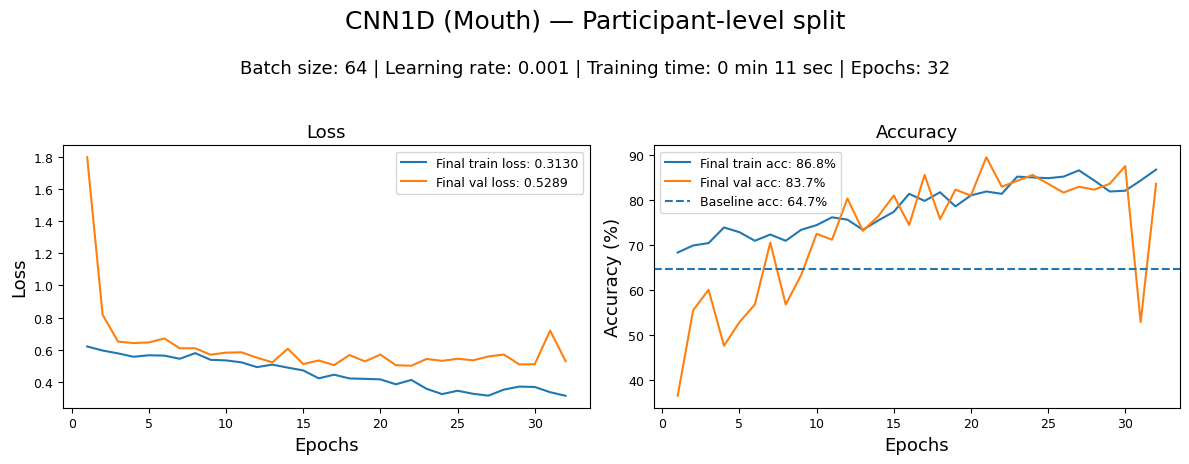

In [23]:
# BEST hyperparams: {'batch_size': 32, 'epochs': 60, 'lr': 0.001,
#  'p_drop': 0.2, 'patience': 10, 'val_acc': 0.7619047619047619, 'time_sec': 8.513104677200317}
model = CNN1D(in_ch=2, p_drop=0.4)
t0 = time.time()
model, trL, vaL, trA, vaA, trP , valP ,_ = train_model_with_loaders(
    model,
    train_loader,
    val_loader,
    epochs=60,
    lr=1e-1,
    patience=10,
    use_pos_weight=False
)

print("Final train acc:", trA[-1])
print("Final val acc:", vaA[-1])


import time

baseline_acc = max(np.mean(y_val_p == 0), np.mean(y_val_p == 1))  # participant-level baseline

t1 = time.time()

training_curve_plot(
    title="CNN1D (Mouth) — Participant-level split",
    train_losses=trL,
    val_losses=vaL,
    train_accs=trA,
    val_accs=vaA,
    batch_size=64,
    learning_rate=1e-3,
    training_time=(t1 - t0),
    baseline_acc=baseline_acc
)


In [24]:
from sklearn.model_selection import train_test_split, ParameterGrid
import numpy as np
import time

# ----- 1) split participants: (train+val) vs test -----
P, W, C, L = X_nose.shape
idx = np.arange(P)

trainval_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y_nose
)

# ----- 2) split trainval participants: train vs val (for tuning) -----
train_idx, val_idx = train_test_split(
    trainval_idx, test_size=0.25, random_state=42, stratify=y_nose[trainval_idx]
)
# (0.25 of 0.8 = 0.2) => 60/20/20 overall

def make_window_loaders_from_participants(X, y, train_idx, val_idx, batch_size=64):
    X_train_p, y_train_p = X[train_idx], y[train_idx]
    X_val_p,   y_val_p   = X[val_idx],   y[val_idx]

    # fit normalization on TRAIN only
    mu = X_train_p.mean(axis=(0,1,3), keepdims=True)          # (1,1,C,1)
    sd = X_train_p.std(axis=(0,1,3), keepdims=True) + 1e-8

    X_train_p = (X_train_p - mu) / sd
    X_val_p   = (X_val_p   - mu) / sd

    # flatten windows
    P_tr, W, C, L = X_train_p.shape
    P_va = X_val_p.shape[0]

    X_train = X_train_p.reshape(P_tr*W, C, L)
    y_train = np.repeat(y_train_p, W)

    X_val   = X_val_p.reshape(P_va*W, C, L)
    y_val   = np.repeat(y_val_p, W)

    train_loader = DataLoader(WindowDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(WindowDataset(X_val,   y_val),   batch_size=128, shuffle=False)
    return train_loader, val_loader, (mu, sd)

# ----- 3) define search space -----
grid = {
    "lr": [1e-3, 3e-4],
    "batch_size": [32, 64],
    "p_drop": [0.0, 0.2, 0.4],
    "epochs": [60],
    "patience": [10],
}

results = []
best = None

# for hp in ParameterGrid(grid):
#     train_loader, val_loader, _ = make_window_loaders_from_participants(
#         X_nose, y_nose, train_idx, val_idx, batch_size=hp["batch_size"]
#     )

#     model = CNN1D(in_ch=2, p_drop=hp["p_drop"])

#     t0 = time.time()
#     model, trL, vaL, trA, vaA, _ = train_model_with_loaders(
#         model,
#         train_loader,
#         val_loader,
#         epochs=hp["epochs"],
#         lr=hp["lr"],
#         patience=hp["patience"],
#         use_pos_weight=False
#     )
#     t1 = time.time()
#     # ai used here 
#     score = vaA[-1]  # validation accuracy (window-level) at end / best depending on your trainer
#     results.append({**hp, "val_acc": float(score), "time_sec": float(t1-t0)})

#     if (best is None) or (score > best["val_acc"]):
#         best = results[-1]

# print("BEST hyperparams:", best)


In [25]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

y_true, y_pred, y_prop = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:   # use your test_loader
        xb = xb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()

        preds = (probs >= 0.5).astype(int)
        y_prop.append(preds)
        y_pred.append(preds)
        y_true.append(yb.numpy().astype(int))

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
y_prop = np.concatenate(y_prop)

print("TEST accuracy (window-level):", accuracy_score(y_true, y_pred))


TEST accuracy (window-level): 0.5714285714285714


In [26]:
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score

print(f"Accuracy:           {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced acc:       {balanced_accuracy_score(y_true, y_pred):.4f}")
print(f"F1 (positive):      {f1_score(y_true, y_pred):.4f}")
print(f"ROC AUC:            {roc_auc_score(y_true, y_prop):.4f}")
print(f"Average Precision:  {average_precision_score(y_true, y_prop):.4f}")
print("\nCM:\n", confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))

Accuracy:           0.5714
Balanced acc:       0.5123
F1 (positive):      0.3193
ROC AUC:            0.5123
Average Precision:  0.3871

CM:
 [[89 28]
 [53 19]]
              precision    recall  f1-score   support

           0     0.6268    0.7607    0.6873       117
           1     0.4043    0.2639    0.3193        72

    accuracy                         0.5714       189
   macro avg     0.5155    0.5123    0.5033       189
weighted avg     0.5420    0.5714    0.5471       189



In [27]:
baseline = max(np.mean(y_val_p == 0), np.mean(y_val_p == 1))
print("Participant baseline:", baseline)


Participant baseline: 0.6470588235294118


In [28]:
def participant_accuracy(model, X_val_p, y_val_p):
    device = next(model.parameters()).device
    model.eval()
    probs = []
    with torch.no_grad():
        for p in range(X_val_p.shape[0]):
            xb = torch.tensor(X_val_p[p], dtype=torch.float32).to(device)  # (9,4,2048)
            logits = model(xb).view(-1)                                     # (9,)
            pr = torch.sigmoid(logits).mean().item()                        # average over 9 windows
            probs.append(pr)
    preds = (np.array(probs) >= 0.5).astype(int)
    return (preds == y_val_p.astype(int)).mean()

print("Participant-level val acc:", participant_accuracy(model, X_val_p, y_val_p))
print("Participant-level test acc:",participant_accuracy(model, X_test_p, y_test_p))

Participant-level val acc: 0.8235294117647058
Participant-level test acc: 0.5714285714285714


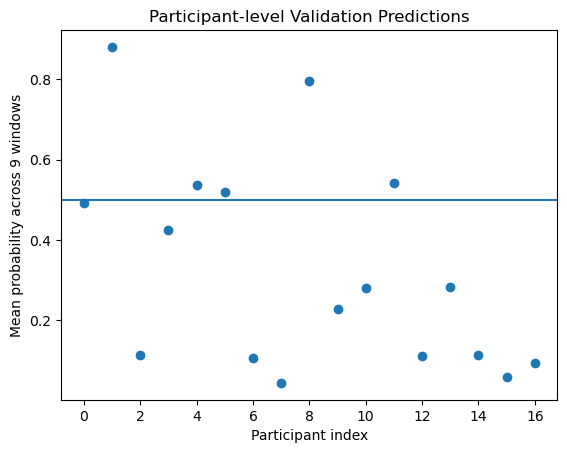

In [29]:
probs = []

model.eval()
with torch.no_grad():
    for p in range(X_val_p.shape[0]): # about 17 idividual
        xb = torch.tensor(X_val_p[p], dtype=torch.float32).to(device)
        logits = model(xb).view(-1)
        pr = torch.sigmoid(logits).mean().item()
        probs.append(pr)

probs = np.array(probs)


plt.figure()
plt.scatter(range(len(probs)), probs)
plt.axhline(0.5)
plt.xlabel("Participant index")
plt.ylabel("Mean probability across 9 windows")
plt.title("Participant-level Validation Predictions")
plt.show()
